# Call Abandonment — Exploratory Analysis

Interrogating the synthetic contact-centre dataset before building the Tableau dashboard, so the dashboard is built around a known story rather than blind.

**Checks run:**
1. Overall health — is the blended abandonment rate believable? per-queue breakdown
2. Did the injected seasonal events land? (freeze-thaw, April bill, summer, autumn storm)
3. Is abandonment diagnosable? — occupancy, forecast variance, interval volume
4. Shrinkage — capacity lost, and its relationship to abandonment

**Key finding:** abandonment is driven by *forecast accuracy* (primary) and *shrinkage* (secondary), not occupancy.


In [3]:
import pandas as pd

DATA_FILE = "wfm_aggregates.xlsx"  

xls = pd.ExcelFile(DATA_FILE)
print("Sheets:", xls.sheet_names)

# load the interval-level sheet (adjust the name if yours differs)
iv = pd.read_excel(DATA_FILE, sheet_name=xls.sheet_names[0])
print("Shape:", iv.shape)
print("\nColumns:")
for c in iv.columns:
    print("  ", c)
print("\nDtypes:\n", iv.dtypes)
iv.head()

Sheets: ['Interval_Aggregate', 'Daily_Aggregate']
Shape: (49752, 17)

Columns:
   date
   interval_start
   day_of_week
   queue
   offered
   answered
   abandoned
   abandonment_rate
   asa_sec
   service_level_pct
   avg_handle_time_sec
   agents_scheduled
   agents_available
   occupancy_pct
   forecast_volume
   forecast_variance
   avg_time_to_abandon_sec

Dtypes:
 date                        object
interval_start              object
day_of_week                 object
queue                       object
offered                      int64
answered                     int64
abandoned                    int64
abandonment_rate           float64
asa_sec                    float64
service_level_pct          float64
avg_handle_time_sec        float64
agents_scheduled             int64
agents_available             int64
occupancy_pct              float64
forecast_volume            float64
forecast_variance          float64
avg_time_to_abandon_sec    float64
dtype: object


,date,interval_start,day_of_week,queue,offered,answered,abandoned,abandonment_rate,asa_sec,service_level_pct,avg_handle_time_sec,agents_scheduled,agents_available,occupancy_pct,forecast_volume,forecast_variance,avg_time_to_abandon_sec
0,2025-01-01,08:00,Wednesday,Water Supply,4,3,1,0.25,0.0,75.0,330.3,3,2,27.5,3.1,0.9,117.1
1,2025-01-01,08:00,Wednesday,Wastewater & Flooding,4,3,1,0.25,5.7,75.0,374.9,3,2,31.2,2.4,1.6,37.2
2,2025-01-01,08:30,Wednesday,Water Supply,2,2,0,0.00,0.0,100.0,213.2,5,4,5.9,3.4,-1.4,0.0
3,2025-01-01,08:30,Wednesday,Wastewater & Flooding,1,1,0,0.00,0.0,100.0,162.8,3,2,4.5,2.3,-1.3,0.0
4,2025-01-01,09:00,Wednesday,Water Supply,3,3,0,0.00,0.0,100.0,448.5,5,4,18.7,5.6,-2.6,0.0


In [4]:
import pandas as pd
import numpy as np

DATA_FILE = "wfm_aggregates.xlsx"   # <-- your real filename

iv = pd.read_excel(DATA_FILE, sheet_name="Interval_Aggregate")
iv["date"] = pd.to_datetime(iv["date"])
print(f"Loaded {len(iv):,} interval rows, {iv['date'].min().date()} -> {iv['date'].max().date()}")

Loaded 49,752 interval rows, 2025-01-01 -> 2025-12-31


In [5]:
tot_off = iv["offered"].sum()
tot_abn = iv["abandoned"].sum()
tot_ans = iv["answered"].sum()
blended = tot_abn / tot_off

print(f"Total offered   : {tot_off:,.0f}")
print(f"Total answered  : {tot_ans:,.0f}")
print(f"Total abandoned : {tot_abn:,.0f}")
print(f"Blended abandon : {blended:.2%}   (sanity target ~4-9%)")

print("\nAbandonment by queue (worst first):")
by_q = (iv.groupby("queue")
          .agg(offered=("offered","sum"), abandoned=("abandoned","sum"))
          .assign(rate=lambda d: d.abandoned / d.offered)
          .sort_values("rate", ascending=False))
for q, r in by_q.iterrows():
    print(f"  {q[:32]:32s} offered {r.offered:9,.0f}   abandon {r.rate:6.2%}")

Total offered   : 752,972
Total answered  : 672,719
Total abandoned : 80,253
Blended abandon : 10.66%   (sanity target ~4-9%)

Abandonment by queue (worst first):
  Billing & Payments               offered   254,214   abandon 12.67%
  Water Supply                     offered   185,671   abandon 11.43%
  Complaints                       offered    35,289   abandon 10.27%
  Wastewater & Flooding            offered   114,109   abandon  9.99%
  Payment Support                  offered    50,424   abandon  8.23%
  Move Home                        offered    56,523   abandon  7.44%
  Metering & Readings              offered    56,742   abandon  6.06%


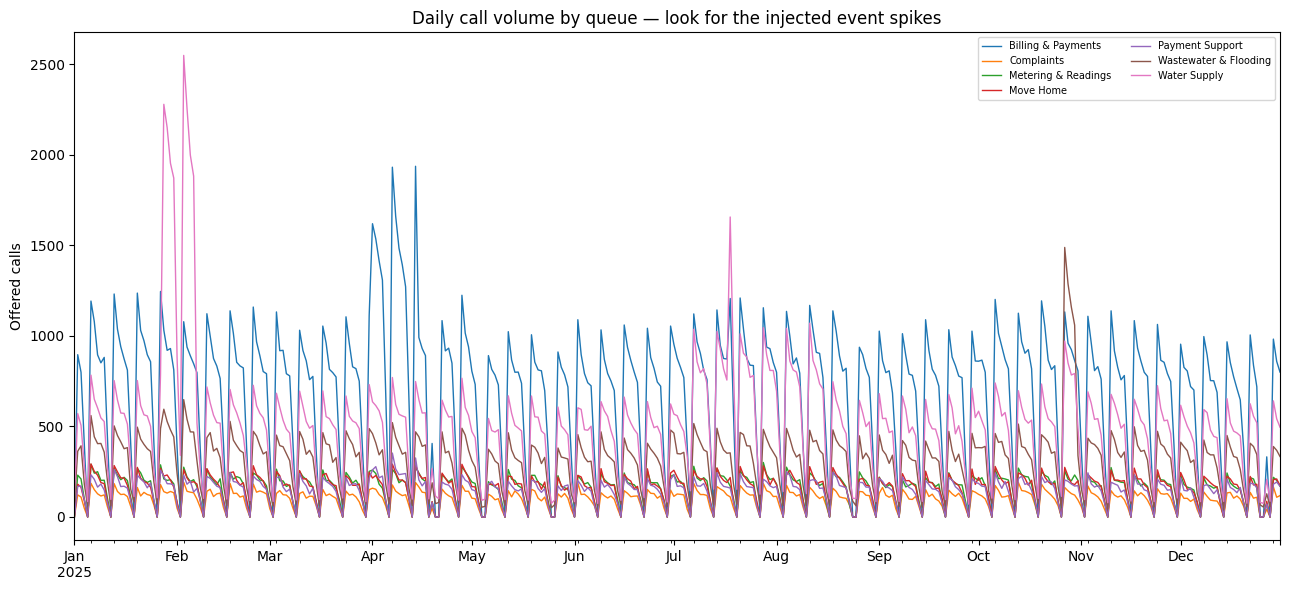

Peak volume day per queue (candidate event signatures):
  Billing & Payments           peak 2025-04-14  ( 2.4x median)
  Complaints                   peak 2025-02-03  ( 1.7x median)
  Metering & Readings          peak 2025-07-28  ( 1.6x median)
  Move Home                    peak 2025-01-06  ( 1.6x median)
  Payment Support              peak 2025-04-07  ( 2.2x median)
  Wastewater & Flooding        peak 2025-10-27  ( 4.3x median)
  Water Supply                 peak 2025-02-03  ( 4.9x median)


In [6]:
import matplotlib.pyplot as plt

# daily volume per queue
daily_q = iv.groupby(["date", "queue"])["offered"].sum().reset_index()
pivot = daily_q.pivot(index="date", columns="queue", values="offered").fillna(0)

# --- plot ---
fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(ax=ax, linewidth=1.0)
ax.set_title("Daily call volume by queue — look for the injected event spikes")
ax.set_ylabel("Offered calls"); ax.set_xlabel("")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

# --- peak day per queue (text, easy to sanity-check) ---
print("Peak volume day per queue (candidate event signatures):")
for q in pivot.columns:
    s = pivot[q]
    peak_day = s.idxmax()
    ratio = s.max() / max(s.median(), 1)
    print(f"  {q[:28]:28s} peak {peak_day.date()}  ({ratio:4.1f}x median)")

In [7]:
d = iv[iv["offered"] > 0].copy()

d["occ_bin"] = pd.cut(d["occupancy_pct"],
                      bins=[0,60,70,75,80,85,90,95,100,999],
                      labels=["<60","60-70","70-75","75-80","80-85","85-90","90-95","95-100","100+"])

def wavg(g):
    w = g["offered"].sum()
    if w == 0:                      # empty band -> skip the division
        return pd.Series({"intervals": 0, "abandon": np.nan})
    return pd.Series({
        "intervals": len(g),
        "abandon": np.average(g["abandonment_rate"], weights=g["offered"])
    })

binned = d.groupby("occ_bin", observed=True).apply(wavg).dropna()

print("Abandonment rate by occupancy band (volume-weighted):")
for b, r in binned.iterrows():
    bar = "#" * int(min(r.abandon, 0.5) / 0.5 * 40)
    print(f"  occ {str(b):7s}  n={int(r.intervals):5d}   abandon {r.abandon:6.2%}  {bar}")

corr = d[["forecast_variance","abandonment_rate"]].corr().iloc[0,1]
print(f"\nCorrelation(forecast_variance, abandonment_rate) = {corr:+.3f}")

Abandonment rate by occupancy band (volume-weighted):
  occ <60      n=44188   abandon 11.24%  ########
  occ 60-70    n= 4550   abandon  8.99%  #######
  occ 70-75    n=  543   abandon  8.24%  ######
  occ 75-80    n=  109   abandon  7.69%  ######
  occ 80-85    n=   14   abandon  4.51%  ###
  occ 85-90    n=    4   abandon  4.88%  ###

Correlation(forecast_variance, abandonment_rate) = +0.660


/var/folders/w9/njhnn_m101dbn0v_2bx160m40000gn/T/ipykernel_73702/3258819786.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  binned = d.groupby("occ_bin", observed=True).apply(wavg).dropna()


In [8]:
d = iv[iv["offered"] > 0].copy()

# 1) How busy does this centre EVER get?
print("Occupancy distribution (percentiles):")
print(d["occupancy_pct"].describe(percentiles=[.5,.75,.9,.95,.99]).round(1))

# 2) Abandonment by forecast-variance band (the candidate REAL story)
d["fvar_bin"] = pd.qcut(d["forecast_variance"], q=6, duplicates="drop")
fv = (d.groupby("fvar_bin", observed=True)
        .apply(lambda g: pd.Series({
            "intervals": len(g),
            "abandon": np.average(g["abandonment_rate"], weights=g["offered"])
        })))
print("\nAbandonment by forecast-variance band (neg = over-forecast, pos = under-forecast):")
for b, r in fv.iterrows():
    bar = "#" * int(min(r.abandon, 0.5)/0.5*40)
    print(f"  {str(b):22s} n={int(r.intervals):5d}  abandon {r.abandon:6.2%}  {bar}")

# 3) Abandonment by interval VOLUME (small-queue effect check)
d["vol_bin"] = pd.cut(d["offered"], bins=[0,3,6,10,20,40,9999],
                      labels=["1-3","4-6","7-10","11-20","21-40","40+"])
vb = (d.groupby("vol_bin", observed=True)
        .apply(lambda g: pd.Series({
            "intervals": len(g),
            "calls": g["offered"].sum(),
            "abandon": np.average(g["abandonment_rate"], weights=g["offered"])
        })))
print("\nAbandonment by interval volume (are small intervals the abandoners?):")
for b, r in vb.iterrows():
    bar = "#" * int(min(r.abandon, 0.5)/0.5*40)
    print(f"  vol {str(b):6s} n={int(r.intervals):5d} calls={int(r.calls):8,d}  abandon {r.abandon:6.2%}  {bar}")

Occupancy distribution (percentiles):
count    49419.0
mean        39.7
std         15.8
min          0.0
50%         40.2
75%         51.9
90%         60.4
95%         64.6
99%         71.0
max         89.7
Name: occupancy_pct, dtype: float64

Abandonment by forecast-variance band (neg = over-forecast, pos = under-forecast):
  (-25.901, -3.0]        n= 8326  abandon  0.99%  
  (-3.0, -1.3]           n= 8223  abandon  1.82%  #
  (-1.3, 0.0]            n= 8187  abandon  2.57%  ##
  (0.0, 1.5]             n= 8376  abandon  4.17%  ###
  (1.5, 3.7]             n= 8120  abandon  7.31%  #####
  (3.7, 117.1]           n= 8187  abandon 25.03%  ####################

Abandonment by interval volume (are small intervals the abandoners?):
  vol 1-3    n= 5250 calls=  12,066  abandon  0.94%  
  vol 4-6    n= 9407 calls=  47,503  abandon  2.68%  ##
  vol 7-10   n=11010 calls=  92,190  abandon  5.35%  ####
  vol 11-20  n=11673 calls= 170,288  abandon  7.29%  #####
  vol 21-40  n= 8767 calls= 252,925  

/var/folders/w9/njhnn_m101dbn0v_2bx160m40000gn/T/ipykernel_73702/2068915521.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/var/folders/w9/njhnn_m101dbn0v_2bx160m40000gn/T/ipykernel_73702/2068915521.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [9]:
d = iv[(iv["offered"] > 0) & (iv["agents_scheduled"] > 0)].copy()

# realised shrinkage per interval = fraction of scheduled agents NOT available
d["shrinkage"] = 1 - (d["agents_available"] / d["agents_scheduled"])

print("Realised shrinkage (1 - available/scheduled):")
print(d["shrinkage"].describe(percentiles=[.25,.5,.75,.9]).round(3))

# total FTE lost to shrinkage over the year
lost = (d["agents_scheduled"] - d["agents_available"]).sum()
sched = d["agents_scheduled"].sum()
print(f"\nAgent-intervals scheduled: {sched:,}  |  lost to shrinkage: {lost:,}  ({lost/sched:.1%})")

# does abandonment rise with shrinkage?
d["shr_bin"] = pd.cut(d["shrinkage"], bins=[-0.01,0.2,0.25,0.3,0.35,0.4,1.0],
                      labels=["<20%","20-25%","25-30%","30-35%","35-40%","40%+"])
sb = (d.groupby("shr_bin", observed=True)
        .apply(lambda g: pd.Series({
            "intervals": len(g),
            "abandon": np.average(g["abandonment_rate"], weights=g["offered"])
        })))
print("\nAbandonment by shrinkage band:")
for b, r in sb.iterrows():
    bar = "#" * int(min(r.abandon,0.5)/0.5*40)
    print(f"  shrink {str(b):7s} n={int(r.intervals):5d}  abandon {r.abandon:6.2%}  {bar}")

Realised shrinkage (1 - available/scheduled):
count    49419.000
mean         0.294
std          0.047
min          0.200
25%          0.250
50%          0.312
75%          0.333
90%          0.333
max          0.333
Name: shrinkage, dtype: float64

Agent-intervals scheduled: 448,266  |  lost to shrinkage: 133,942  (29.9%)

Abandonment by shrinkage band:
  shrink <20%    n= 6012  abandon  2.69%  ##
  shrink 20-25%  n=10055  abandon  4.20%  ###
  shrink 25-30%  n= 1224  abandon  8.07%  ######
  shrink 30-35%  n=32128  abandon 12.30%  #########


/var/folders/w9/njhnn_m101dbn0v_2bx160m40000gn/T/ipykernel_73702/647262562.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


csv


In [10]:
# Export Tableau-ready CSVs from the interval data already in memory (iv)
import os
os.makedirs("tableau_data", exist_ok=True)

# main fact file — add a few helper columns Tableau will thank you for
tab = iv.copy()
tab["hour"] = pd.to_datetime(tab["interval_start"].astype(str)).dt.hour
tab["month"] = tab["date"].dt.month_name()
tab["month_num"] = tab["date"].dt.month
tab["is_under_forecast"] = (tab["forecast_variance"] > 0)
tab["shrinkage"] = 1 - (tab["agents_available"] / tab["agents_scheduled"].replace(0, pd.NA))

tab.to_csv("tableau_data/interval_facts.csv", index=False)

# tiny date dimension
dates = pd.DataFrame({"date": pd.date_range(iv["date"].min(), iv["date"].max())})
dates["day_of_week"] = dates["date"].dt.day_name()
dates["month"] = dates["date"].dt.month_name()
dates["is_weekend"] = dates["date"].dt.dayofweek >= 5
dates.to_csv("tableau_data/date_dim.csv", index=False)

print("Wrote tableau_data/interval_facts.csv and date_dim.csv")

Wrote tableau_data/interval_facts.csv and date_dim.csv


/var/folders/w9/njhnn_m101dbn0v_2bx160m40000gn/T/ipykernel_73702/2242226541.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tab["hour"] = pd.to_datetime(tab["interval_start"].astype(str)).dt.hour


In [11]:
import os
print(os.path.abspath("tableau_data"))
print(os.listdir("tableau_data"))

project/SWW_call_drop_analysis/tableau_data
['interval_facts.csv', 'date_dim.csv', '.ipynb_checkpoints']
